# Introduction to Dynamic Models --- Instructor Solutions

This is the **instructor answer key** for the three exercises in
[`notebooks/01_ode_intro.ipynb`](../notebooks/01_ode_intro.ipynb). For each exercise it gives:

1. a full derivation or worked reasoning (not just the answer),
2. the completed code, runnable end-to-end, and
3. **teaching notes**: what a fully-correct submission should show, common
   student mistakes, and a talking point/extension if there's time.

**Not for distribution to students before the exercise deadline.** This notebook
is excluded from the published Quarto site (see `_quarto.yml`'s `!instructor/`
render rule) but is still committed to the repo history like any other file.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Setup from the student notebook
def exp_model(t, N, r):
    return r * N

def logistic_model(t, N, r, K):
    return r * N * (1 - N / K)

def birth_death(t, x, k_in, k_deg):
    return k_in - k_deg * x


## Exercise 1: Varying $r$ and $K$ in the Logistic Model

### Derivation

The logistic ODE has a closed-form solution (worth deriving once so students see
where the printed numbers come from, even though the exercise itself only asks for
simulation):

$$
N(t) = \frac{K}{1 + \left(\frac{K-N_0}{N_0}\right)e^{-rt}}.
$$

Solving for the time $t_{95}$ at which $N$ first reaches $0.95K$ gives

$$
t_{95} = \frac{1}{r}\ln\!\left(\frac{19(K-N_0)}{N_0}\right)
$$

(from $0.95 = 1/(1+Ce^{-rt})$ with $C=(K-N_0)/N_0$, solved for $t$). Two things fall
out of this formula that the exercise is really testing:

- **$r$ enters as a simple inverse prefactor** — doubling $r$ exactly halves $t_{95}$,
  for *any* $K$.
- **$K$ only enters inside a logarithm** — quadrupling $K$ (e.g. 50 → 200) barely
  moves $t_{95}$. $K$ sets *how high* the population goes, not *how fast* (in time
  units) it gets there.

This is the same conceptual split as $A_{ss}=k_p/k_d$ elsewhere in the course:
one parameter sets a timescale, a different, unrelated parameter sets a magnitude.


Varying r (K = 100 fixed):
  r=0.2: t95 theory=37.70, numeric=37.68
  r=0.5: t95 theory=15.08, numeric=15.07
  r=1.0: t95 theory=7.54, numeric=7.53

Varying K (r = 0.5 fixed):
  K=   50: t95 theory=13.67, numeric=13.67
  K=  100: t95 theory=15.08, numeric=15.07
  K=  200: t95 theory=16.48, numeric=16.46


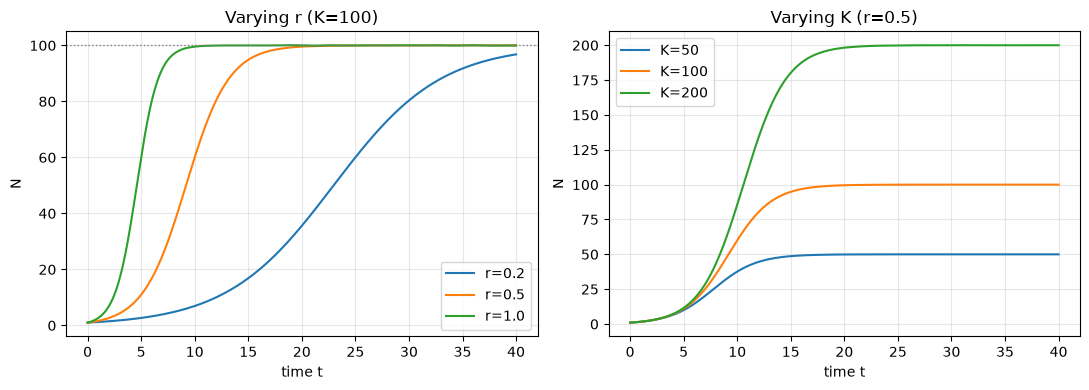

In [2]:
# --- Vary r at fixed K ---
K_fixed = 100.0
r_values = [0.2, 0.5, 1.0]
N0 = 1.0
t_eval = np.linspace(0, 40, 800)

def t95_theory(r, K, N0=1.0):
    return np.log(19 * (K - N0) / N0) / r

def t95_numeric(t, N, K):
    # first crossing of 0.95*K, via linear interpolation
    return np.interp(0.95 * K, N, t)

print("Varying r (K = 100 fixed):")
sols_r = {}
for r in r_values:
    sol = solve_ivp(logistic_model, (0, 40), [N0], t_eval=t_eval, args=(r, K_fixed))
    sols_r[r] = sol
    print(f"  r={r:.1f}: t95 theory={t95_theory(r, K_fixed):.2f}, "
          f"numeric={t95_numeric(sol.t, sol.y[0], K_fixed):.2f}")

# --- Vary K at fixed r ---
r_fixed = 0.5
K_values = [50.0, 100.0, 200.0]
print("\nVarying K (r = 0.5 fixed):")
sols_K = {}
for K in K_values:
    sol = solve_ivp(logistic_model, (0, 40), [N0], t_eval=t_eval, args=(r_fixed, K))
    sols_K[K] = sol
    print(f"  K={K:5.0f}: t95 theory={t95_theory(r_fixed, K):.2f}, "
          f"numeric={t95_numeric(sol.t, sol.y[0], K):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for r, sol in sols_r.items():
    axes[0].plot(sol.t, sol.y[0], label=f"r={r}")
axes[0].axhline(K_fixed, color="gray", ls=":", lw=1)
axes[0].set_title("Varying r (K=100)")
axes[0].legend()
for K, sol in sols_K.items():
    axes[1].plot(sol.t, sol.y[0], label=f"K={K:.0f}")
axes[1].set_title("Varying K (r=0.5)")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("time t")
    ax.set_ylabel("N")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Teaching notes

**What a correct submission looks like:** the theory/numeric $t_{95}$ pair matches
to ~0.1 for every $(r,K)$ combination, the "varying $r$" panel shows curves that are
time-rescaled versions of each other (all reaching the *same* $K=100$ plateau, at
different speeds), and the "varying $K$" panel shows curves reaching *different*
plateaus at *nearly the same* time.

**Common mistakes:**

- Concluding "$K$ makes it grow faster" from the raw plot, because a larger-$K$ curve
  is still climbing when a smaller-$K$ curve has already flattened — that's an
  artifact of the y-axis scale, not a difference in rate. The $t_{95}$ numbers make
  this precise instead of relying on plot-reading intuition.
- Re-using a single `sol` variable inside the loop and only plotting/printing the
  last iteration's result — a classic silent bug when converting a "define once"
  example into "run three times and compare."
- Confusing $r$ (units of 1/time) with $K$ (units of $N$) when picking sweep ranges,
  e.g. trying `r_values = [50, 100, 200]`, which just makes the population blow past
  $K$ before the first `t_eval` point.

**Extension, if there's time:** ask what happens to $t_{95}$ as $N_0 \to K$ (it stays
finite and shrinks toward $0$, since $C\to 0$ and there's ~nothing left to grow) versus
$N_0 \to 0^+$ (it diverges, logarithmically) — this previews why growth curves with a
very small founding population show a long, flat "lag phase" before the visible rise.


## Exercise 2: Two Initial Conditions — Exponential vs. Logistic

### Derivation

**Exponential.** $N(t)=N_0e^{rt}$ is *linear* in $N_0$: for two initial conditions
$N_0^{(1)}, N_0^{(2)}$ with the same $r$,

$$
\frac{N^{(2)}(t)}{N^{(1)}(t)} = \frac{N_0^{(2)}}{N_0^{(1)}} \quad\text{for all } t.
$$

The ratio is fixed **forever** — the model never forgets its initial condition; on a
log-scale plot the two trajectories are exactly parallel straight lines, never
converging or crossing.

**Logistic.** The nonlinear $-rN^2/K$ term is a negative feedback that depends on
how close $N$ already is to $K$, not on where it started. As $t\to\infty$,
$N(t)\to K$ for *any* $N_0>0$ — from below (monotonically increasing, if $N_0<K$) or
from above (monotonically decreasing, if $N_0>K$). The model "forgets" its initial
condition asymptotically; only $K$ survives.

This is the qualitative contrast the exercise is after: unbounded linear growth
preserves initial-condition information indefinitely, saturating nonlinear growth
erases it.


Exponential N0 ratio target: 5.0000
Exponential N_b/N_a over time: min=5.0000, max=5.0000 (should be identical to the target)

Logistic final values: from below N0=1.0 -> 99.554, from above N0=150.0 -> 100.005  (both -> K=100.0)


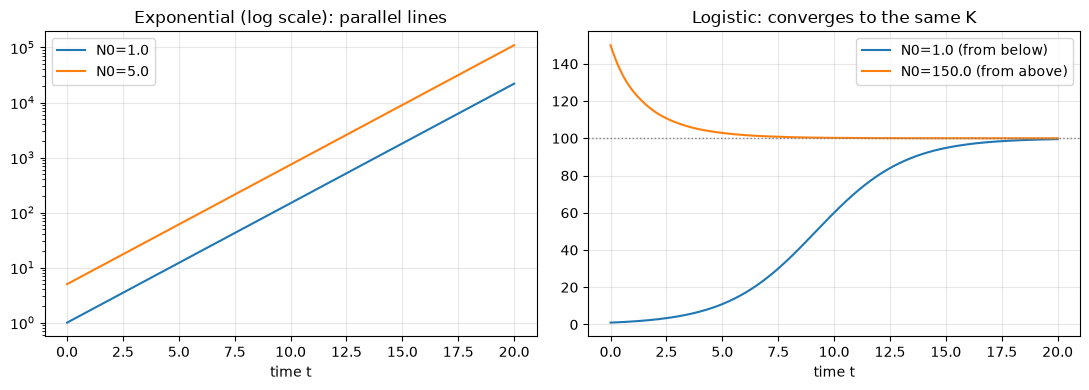

In [3]:
r, K = 0.5, 100.0
t_eval = np.linspace(0, 20, 400)

# Exponential: two initial conditions
N0_exp_a, N0_exp_b = 1.0, 5.0
sol_exp_a = solve_ivp(exp_model, (0, 20), [N0_exp_a], t_eval=t_eval, args=(r,))
sol_exp_b = solve_ivp(exp_model, (0, 20), [N0_exp_b], t_eval=t_eval, args=(r,))
ratio_exp = sol_exp_b.y[0] / sol_exp_a.y[0]
print(f"Exponential N0 ratio target: {N0_exp_b / N0_exp_a:.4f}")
print(f"Exponential N_b/N_a over time: min={ratio_exp.min():.4f}, "
      f"max={ratio_exp.max():.4f} (should be identical to the target)")

# Logistic: one IC below K, one above K
N0_log_a, N0_log_b = 1.0, 150.0
sol_log_a = solve_ivp(logistic_model, (0, 20), [N0_log_a], t_eval=t_eval, args=(r, K))
sol_log_b = solve_ivp(logistic_model, (0, 20), [N0_log_b], t_eval=t_eval, args=(r, K))
print(f"\nLogistic final values: from below N0={N0_log_a} -> {sol_log_a.y[0, -1]:.3f}, "
      f"from above N0={N0_log_b} -> {sol_log_b.y[0, -1]:.3f}  (both -> K={K})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(sol_exp_a.t, sol_exp_a.y[0], label=f"N0={N0_exp_a}")
axes[0].semilogy(sol_exp_b.t, sol_exp_b.y[0], label=f"N0={N0_exp_b}")
axes[0].set_title("Exponential (log scale): parallel lines")
axes[0].legend()
axes[1].plot(sol_log_a.t, sol_log_a.y[0], label=f"N0={N0_log_a} (from below)")
axes[1].plot(sol_log_b.t, sol_log_b.y[0], label=f"N0={N0_log_b} (from above)")
axes[1].axhline(K, color="gray", ls=":", lw=1)
axes[1].set_title("Logistic: converges to the same K")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("time t")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Teaching notes

**What a correct submission looks like:** the exponential ratio is constant to
machine precision across the whole run (no drift), and both logistic runs land
within numerical tolerance of $K=100$ by $t=20$ — one approaching from below, one
from above, meeting at the same plateau.

**Common mistakes:**

- Picking $N_0 > K$ for the logistic run and treating a *decreasing* curve as a bug
  — it's the correct, expected behavior of $dN/dt=rN(1-N/K)<0$ when $N>K$, not an
  error to "fix."
- Testing the exponential model with $N_0>K$-style large values and expecting
  saturation — the exponential model has no $K$ at all; nothing bounds it.
- Comparing the two exponential curves on a **linear** y-axis and concluding "they
  diverge" — true in absolute terms, but the constant-ratio structure (the actual
  point of the exercise) is only visible on a log axis or by explicitly computing
  the ratio array, as done above.

**Extension, if there's time:** ask what the exponential ratio would do if the two
runs used *different* $r$ instead of different $N_0$ — now $N^{(2)}/N^{(1)} =
(N_0^{(2)}/N_0^{(1)})\,e^{(r_2-r_1)t}$ grows or shrinks without bound, i.e. only
matched growth rates give the "memory forever, but a fixed memory" behavior seen
here.


## Exercise 3: Steady State vs. Degradation Rate

### Derivation

At steady state, $0 = k_{in} - k_{deg}\,x_{ss} \Rightarrow x_{ss}=k_{in}/k_{deg}$ —
a hyperbola in $k_{deg}$, needing no simulation at all to plot. The part worth
instructor attention is the **grading gotcha**: the birth-death ODE relaxes toward
$x_{ss}$ on timescale $1/k_{deg}$ (its only rate constant), so a student who instead
*simulates* to some fixed `t_span` and reads off the final value, rather than using
the closed form directly, will get systematically **worse** agreement with
$k_{in}/k_{deg}$ as $k_{deg}$ shrinks — the run simply hasn't reached steady state
yet. This mirrors the earlier "how long is long enough" pitfall for the
production/reversible-conversion system in the mass-action notebook, now in its
simplest possible one-equation form.


At the fastest k_deg=2.00 (relaxation time 1/k_deg=0.50): relative error = 2.82e-04
At the slowest k_deg=0.10 (relaxation time 1/k_deg=10.00, close to t_span=10): relative error = 3.68e-01


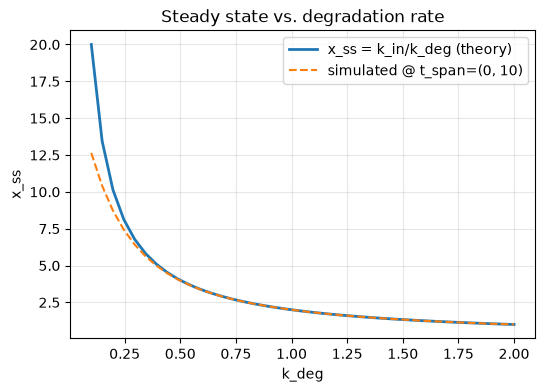

In [4]:
k_in = 2.0
k_deg_values = np.linspace(0.1, 2.0, 40)
x_ss_theory = k_in / k_deg_values

# Simulation-based check at a FIXED t_span, to expose the relaxation-time pitfall
t_span_fixed = (0, 10)
x_ss_simulated = np.array([
    solve_ivp(birth_death, t_span_fixed, [0.0], args=(k_in, k_deg)).y[0, -1]
    for k_deg in k_deg_values
])
rel_err = np.abs(x_ss_simulated - x_ss_theory) / x_ss_theory
print(f"At the fastest k_deg={k_deg_values[-1]:.2f} (relaxation time "
      f"1/k_deg={1/k_deg_values[-1]:.2f}): relative error = {rel_err[-1]:.2e}")
print(f"At the slowest k_deg={k_deg_values[0]:.2f} (relaxation time "
      f"1/k_deg={1/k_deg_values[0]:.2f}, close to t_span={t_span_fixed[1]}): "
      f"relative error = {rel_err[0]:.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_deg_values, x_ss_theory, label="x_ss = k_in/k_deg (theory)", lw=2)
ax.plot(k_deg_values, x_ss_simulated, "--", label=f"simulated @ t_span={t_span_fixed}")
ax.set_xlabel("k_deg")
ax.set_ylabel("x_ss")
ax.set_title("Steady state vs. degradation rate")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


### Teaching notes

**What a correct submission looks like:** a smoothly decreasing hyperbola, ideally
plotted directly from the closed form; a submission that *simulates* for each
`k_deg` should show the two curves diverging at small `k_deg` (as demonstrated
above) and should recognize that as a fixed-`t_span` artifact rather than debug the
ODE itself.

**Common mistakes:**

- Solving `solve_ivp` for every `k_deg` value with a **fixed** `t_span` (as many
  students will default to, copying the pattern from earlier cells) without
  checking whether that span is long enough relative to $1/k_{deg}$ — silently
  wrong for the smallest `k_deg` values in the sweep.
- Forgetting $x_{ss}$ doesn't depend on the initial condition at all — re-deriving
  it "for $x_0=0$" as if that were a special case, when it holds for any $x_0$.

**Extension, if there's time:** connect back to biology — $k_{deg}$ here plays the
role of a protein's degradation/dilution rate. A long-lived protein (small
$k_{deg}$) needs a *much* longer observation window before its steady-state level
can be read off an experimental time course, exactly the same pitfall as the
simulated curve above.


## Grading rubric summary

| Exercise | Full marks requires | Partial credit for |
|---|---|---|
| 1. Varying $r$, $K$ | Both sweeps implemented; $t_{95}$ computed (not just eyeballed from the plot); correct qualitative read (r sets speed, K sets height) | Plots only, no $t_{95}$ quantification |
| 2. Two initial conditions | Exponential ratio shown constant; logistic shown converging from both below and above; correct explanation of *why* | Correct simulations, but explanation conflates "different final value" with "different behavior" |
| 3. Steady state vs. $k_{deg}$ | Correct hyperbola from the closed form; recognizes/avoids (or explicitly discusses) the fixed-`t_span` relaxation-time pitfall | Correct hyperbola, no discussion of the simulation pitfall |

**Reference:** Ingalls, B. P. (2013). *Mathematical Modeling in Systems Biology: An
Introduction*. MIT Press. Official PDF (with solutions):
<https://www.math.uwaterloo.ca/~bingalls/MMSB/MMSB_w_solutions.pdf>
